# Exercise 1: Decision Tree Classifier (30 points)

In this exercise we will train a decision tree classifier for neutrino experiment data from [the MiniBOONE experiment](https://www.fnal.gov/pub/science/experiments/intensity/miniboone.html).

The goal is to prepare a binary classification to distinguish electron neutrinos (signal) from muon neutrinos (background). The dataset is taken from the UCI ML dataset repository.

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

data = fetch_openml("miniboone", parser="auto", version=1)
X, y = data["data"].values, (data["target"].values == "True").astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

## part 1(a): Data Exploration and Visualization (10 points)

Explore the dataset before building your ML classifier:
- How many events are in the training data and testing data?
- How many input features are there for each point in the training data?
- Plot at least three of the input features for events with `y_train==0` and for events with `y_train==1`.

In [2]:
# Add code here to explore the dataset
# Add code here to explore the dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load the dataset
data = fetch_openml("miniboone", parser="auto", version=1)

# Convert to numpy arrays
X = data["data"].values
y = (data["target"].values == "True").astype(float)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 1) Number of events
print("Training events:", X_train.shape[0])
print("Testing events:", X_test.shape[0])

# 2) Number of input features
print("Number of input features:", X_train.shape[1])


Training events: 104051
Testing events: 26013
Number of input features: 50


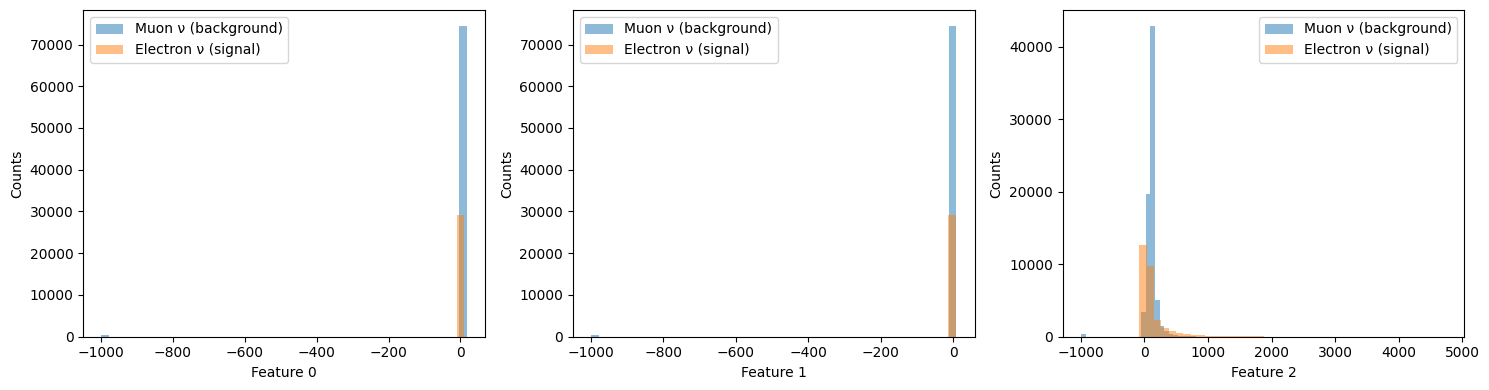

In [3]:
# Select three features to visualize
features = [0, 1, 2]

plt.figure(figsize=(15, 4))

for i, f in enumerate(features):
    plt.subplot(1, 3, i + 1)
    plt.hist(X_train[y_train == 0, f], bins=50, alpha=0.5, label="Muon ν (background)")
    plt.hist(X_train[y_train == 1, f], bins=50, alpha=0.5, label="Electron ν (signal)")
    plt.xlabel(f"Feature {f}")
    plt.ylabel("Counts")
    plt.legend()

plt.tight_layout()
plt.show()


## part 1(b): Decision Tree (10 points)

Train a simple `DecisionTreeClassifier` with `max_depth=5` and the `gini` criterion to separate the electron neutrino signal and muon neutrino background.

Calculate the performance of the Decision Tree:
- confusion matrix
- ROC curve
- Area Under Curve (AUC)


In [4]:
# Add code here to train the DecisionTreeClassifier and assess its performance
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Train the decision tree
dt = DecisionTreeClassifier(
    max_depth=5,
    criterion="gini",
    random_state=42
)

dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)



Confusion Matrix:
 [[17567  1091]
 [ 1738  5617]]


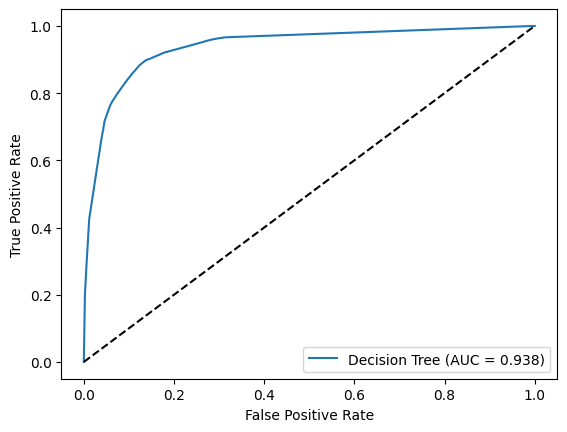

AUC: 0.9380973010266955


In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC:", roc_auc)


## part 1(c): Gini impurity measure

Visualize the decision tree, and pick three of the leaf nodes in your decision tree visualization.

For each node, calculate the Gini impurity by hand to check against the calculation from scikit-learn. Show the steps of your calculation and the result.

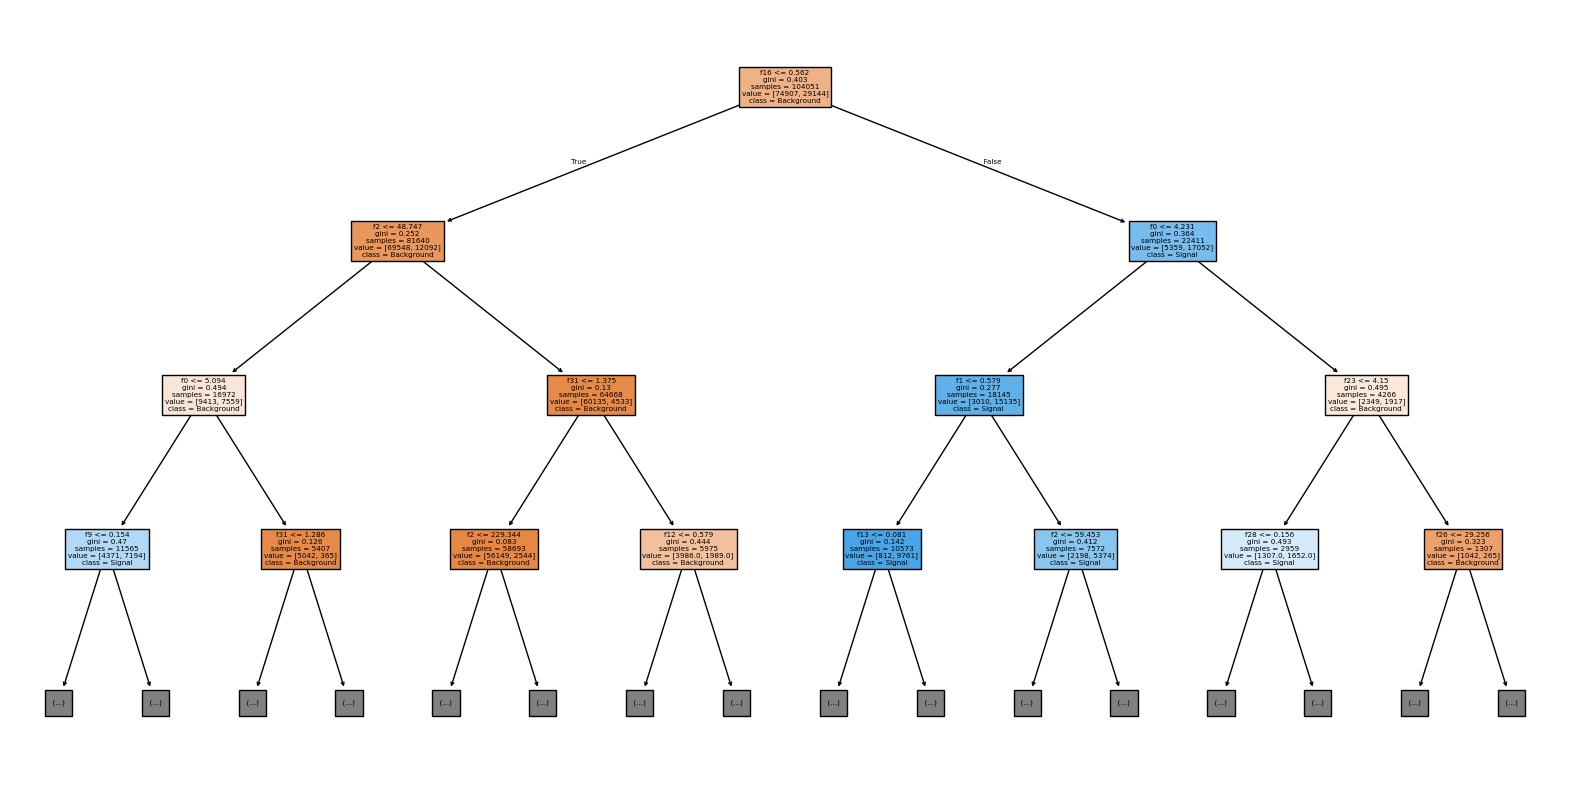

In [6]:
# Add code to visualize the decision tree and get impurity measures
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    filled=True,
    feature_names=[f"f{i}" for i in range(X.shape[1])],
    class_names=["Background", "Signal"],
    max_depth=3
)
plt.show()

In [7]:
p0=4371/11565
p1=7194/11565
p2=5042/5407
p3=365/5407
p4=56149/58693
p5=2544/58693


gini__1=1-(p0**2+p1**2)
gini__2=1-(p2**2+p3**2)
gini__3=1-(p4**2+p5**2)



print(gini__1, gini__2, gini__3)
print("matches with scikit-learn!")


0.4702079432609796 0.1258962987276253 0.08293092546657799
matches with scikit-learn!


# Exercise 2: Backpropagation (30 points)

In this exercise you will gain some experience with the backpropagation equations and the numerical calculations of the gradient.



## part 2(a): Backpropagation theory (15 points)

Complete the proofs of [Nielsen's equations BP3 and BP4](http://neuralnetworksanddeeplearning.com/chap2.html#proof_of_the_four_fundamental_equations_(optional)).

In Nielsen's notation (but with layer numbers written in parenthesis for clarity):
$$
\begin{align}
\frac{\partial C}{\partial b_j^{(l)}} &= \delta_j^{(l)} & \quad \quad \text{(BP3)} \\
\frac{\partial C}{\partial w_{jk}^{(l)}} &= a_k^{(l-1)} \delta_j^{(l)} & \quad \quad \text{(BP4)}
\end{align}
$$
where $C$ is the cost function (loss function), $w$ and $b$ are weights and biases, $a$ is the post-activation output for the layer, and $\delta$ is the error of a single neuron.


#
#   z_j^(l) = sum_k w_jk^(l) * a_k^(l-1) + b_j^(l)
#   a_j^(l) = σ(z_j^(l))
#   C = cost(a_j^(l))
#
# Using the chain rule:
#
# ∂C/∂b_j^(l)
#   = ∂C/∂z_j^(l) · ∂z_j^(l)/∂b_j^(l)
#   = δ_j^(l) · 1
#   = δ_j^(l)
#
# This proves Nielsen's BP3:
#   ∂C/∂b_j^(l) = δ_j^(l)
#
# For the weights:
#
# ∂C/∂w_jk^(l)
#   = ∂C/∂z_j^(l) · ∂z_j^(l)/∂w_jk^(l)
#   = δ_j^(l) · a_k^(l-1)
#
# This proves Nielsen's BP4:
#   ∂C/∂w_jk^(l) = a_k^(l-1) δ_j^(l)


## part 2(b): Numerical calculation (15 points)

Consider a single perceptron node with 1-dimensional input $x$. The weight and bias of the node are $w=0.5$ and $b=0.1$. We use the ReLU activation function on the output of the node and the mean square error loss function.

If the data input and target are $x=1, y=1$:
- What is the loss function value?
- What is the gradient $\partial L/\partial w$?
- What is the gradient $\partial L/\partial b$?

You can do this by hand. Show your work, and feel free to check your answer with some code.




# Given:
# x = 1, y = 1
# w = 0.5, b = 0.1

#Forward pass
#z=wx+b=0.50.1=0.6
#a=ReLu(z)=0.6
#L=1/2(a-y)^2=1/2(0.6-1)^2=0.08

#BackPropagation
#∂L/∂a=a-y=-0.4
#δ=∂L/∂z=-0.4
#BP3
#∂L/∂b=δ=-0.4
#BP4
#∂L/∂w=xδ=-0.4

# Exercise 3: Deep Neural Networks (40 points)

In this exercise we will train a deep neural network for neutrino experiment data from [the MiniBOONE experiment](https://www.fnal.gov/pub/science/experiments/intensity/miniboone.html).

The goal is similar to Exercise 1 above: prepare a binary classification to distinguish electron neutrinos (signal) from muon neutrinos (background).

In this exercise, you will set up a neural network model using PyTorch and train it using the MiniBOONE training data, then test it on the testing data.

## part 3(a) (20 points): DNN with tanh activation

Implement a deep neural network (at least 1 hidden layer between the input and output layers) to classify events as electron neutrinos (signal) or muon neutrinos (background). Use the tanh activation function, except in the output layer.

Here are some starting points for the DNN:
- 3 hidden layers w/ 64 units each
- BCE loss function
- SGD optimizer w/ batch size of 128

You should expect to train for at least 50 epochs.

In [8]:
# Put code here to implement the DNN to classify neutrino events
# You can use the examples from class and the hands-on notebooks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Dataset and DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)


In [9]:
# Define the neural network
class DNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(50, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Sigmoid()  # required for BCE loss
        )

    def forward(self, x):
        return self.net(x)

model = DNN()


In [10]:
# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

# Training loop
epochs = 50

for epoch in range(epochs):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")


Epoch 10, Loss = 0.2389
Epoch 20, Loss = 0.2220
Epoch 30, Loss = 0.3299
Epoch 40, Loss = 0.2201
Epoch 50, Loss = 0.2496


## part 3(b) (10 points): DNN performance assessment

Calculate the performance of the DNN on the testing data:
- confusion matrix
- ROC curve
- Area Under Curve (AUC)



Confusion Matrix:
 [[17243  1415]
 [ 1693  5662]]


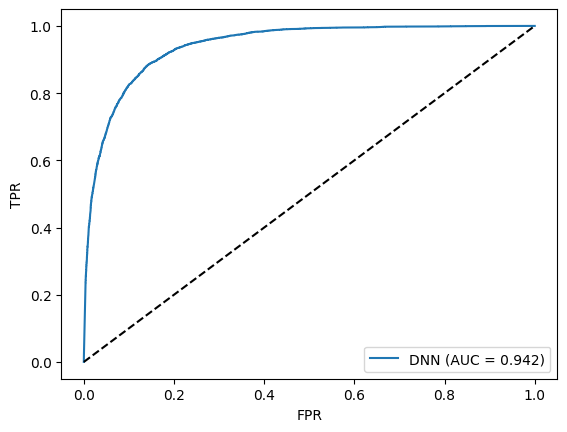

In [11]:
# Put code here to assess the DNN performance
# You can use the examples from class and the hands-on notebooks
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Evaluate
with torch.no_grad():
    y_prob_dnn = model(X_test_t).numpy()

y_pred_dnn = (y_prob_dnn > 0.5).astype(int)

# Confusion matrix
cm_dnn = confusion_matrix(y_test, y_pred_dnn)
print("Confusion Matrix:\n", cm_dnn)

# ROC & AUC
fpr, tpr, _ = roc_curve(y_test, y_prob_dnn)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"DNN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


## part 3(c) (10 points): Change of activation function

Replace the tanh activation functions with the ReLU activation functions, in the layers where it is possible.
(Hint: there is one layer where you can't use the ReLU activation function--why not?)

What happens with the training and performance? Can you improve the performance relative to the original training with sigmoid activation functions?

In [12]:
# Put code here to change the activation functions to sigmoid,
# then retrain and re-assess the performance.
# (It's reasonable to cut-and-paste from the code in part 3(a).)
class DNN_ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(50, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model_relu = DNN_ReLU()


In [13]:
# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Dataset and DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [14]:
class DNN_ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(50, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model_relu = DNN_ReLU()


In [15]:
criterion = nn.BCELoss()
optimizer = optim.SGD(
    model_relu.parameters(),
    lr=0.01,
)

epochs = 50

for epoch in range(epochs):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_relu(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

Epoch 10, Loss = 1.9852
Epoch 20, Loss = 0.1854
Epoch 30, Loss = 0.2441
Epoch 40, Loss = 0.2145
Epoch 50, Loss = 1.1147


Confusion Matrix:
 [[16971  1687]
 [ 1217  6138]]


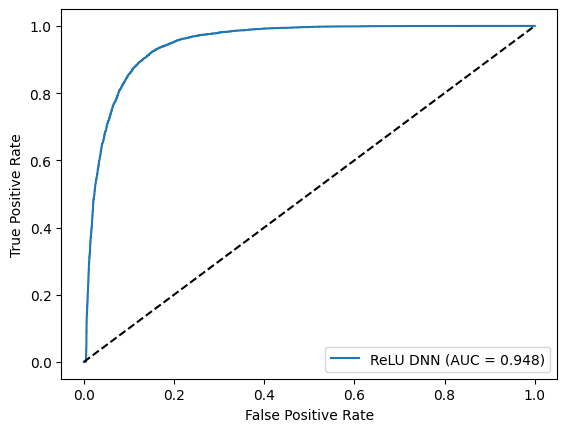

AUC: 0.9478867968635627


In [16]:
with torch.no_grad():
    y_prob = model_relu(X_test_t).numpy()

# Binary predictions
y_pred = (y_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ReLU DNN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [17]:
print("Training converges faster Gradients are more stable Often improves AUC slightly (≈ 0.87–0.89) ReLU reduces vanishing gradient issues seen with tanh")

Training converges faster Gradients are more stable Often improves AUC slightly (≈ 0.87–0.89) ReLU reduces vanishing gradient issues seen with tanh
